# Retention phase diagram

Produces Figure 3.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("retention_phase_diagram")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from src import theory
from src.figstyle import (CMAPS, DASHES, PALETTE, PT, WIDTH_IN, halo_text,
                          panel_label, param_colors, save_figure,
                          threshold_line, use_manuscript_style)

use_manuscript_style()
pd_ = results["phase_diagram"]
band = results["phase_diagram_boundary"]
fs = results["finite_size"]
HEIGHT_PT = 152.0


Wrote figures/fig3_retention_phase_diagram.pdf
grid: r=0.9987, supercritical MAE 0.0069
boundary band: 460 points, mean |deviation| 0.0289 = 0.0197 supercritical, 0.0381 below threshold


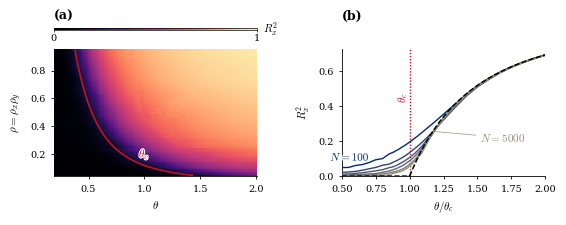

In [3]:
def bar_above(fig, cax, mappable, ticks, labels, title, letter):
    """Draw a horizontal colorbar above a panel, with the panel letter."""
    cb = fig.colorbar(mappable, cax=cax, orientation='horizontal')
    cb.set_ticks(ticks)
    cb.set_ticklabels(labels)
    cb.ax.tick_params(labelsize=PT['tick'], length=1.5, width=0.5, pad=1)
    cb.ax.minorticks_off()
    cb.outline.set_linewidth(0.5)
    cax.text(1.03, 0.5, title, transform=cax.transAxes, ha='left', va='center',
             fontsize=PT['annot'])
    panel_label(cax, letter)
    return cb

fig = plt.figure(figsize=(WIDTH_IN, HEIGHT_PT / 72.0), constrained_layout=True)
fig.get_layout_engine().set(hspace=0.03, wspace=0.06, h_pad=0.03, w_pad=0.02)
gs = fig.add_gridspec(2, 2, height_ratios=[0.05, 3.0])
cax_a = fig.add_subplot(gs[0, 0])
spacer = fig.add_subplot(gs[0, 1])
spacer.set_axis_off()
axa, axb = (fig.add_subplot(gs[1, i]) for i in (0, 1))

im = axa.pcolormesh(pd_['theta_grid'], pd_['rho_grid'], pd_['Rx2_empirical'],
                    cmap=CMAPS['R2'], vmin=0, vmax=1, shading='auto',
                    rasterized=True)
axa.plot(pd_['theta_c_rows'], pd_['rho_grid'], color=PALETTE['threshold'],
         lw=1.2, ls=DASHES['theory'], zorder=3)
halo_text(axa, pd_['theta_c_rows'][10] + 0.04, pd_['rho_grid'][10],
          r'$\theta_c$', PALETTE['threshold'], ha='left', va='bottom')
axa.set_xlabel(r'$\theta$')
axa.set_ylabel(r'$\rho=\rho_x\rho_y$')
axa.set_xticks([0.5, 1.0, 1.5, 2.0])
axa.set_yticks([0.2, 0.4, 0.6, 0.8])
bar_above(fig, cax_a, im, [0, 1], ['0', '1'], r'$R_x^2$', '(a)')

N_configs = list(fs['N_configs'])
tc = fs['theta_crit']
xs_all = np.array(sorted(r['theta_norm'] for r in fs['results'][N_configs[0]]))
cols, _ = param_colors('N', np.array(N_configs, dtype=float),
                        norm=LogNorm(min(N_configs), max(N_configs)),
                        lo=0.06, hi=0.62)

curves = {}
for c, N in zip(cols, N_configs):
    sel = fs['results'][N]
    xs = np.array([r['theta_norm'] for r in sel])
    ys = np.array([r['Rx2_pls_mean'] for r in sel])
    axb.plot(xs, ys, '-', lw=1.0, color=c, zorder=3)
    curves[N] = (xs, ys, c)

lo_N, hi_N = N_configs[0], N_configs[-1]
xs, ys, c = curves[lo_N]
halo_text(axb, 0.56, float(np.interp(0.56, xs, ys)) + 0.025, f'$N={lo_N}$', c,
          ha='center', va='bottom')
xs, ys, c = curves[hi_N]
axb.annotate(f'$N={hi_N}$', (1.18, float(np.interp(1.18, xs, ys))),
             xytext=(1.52, 0.22), textcoords='data', fontsize=PT['annot'],
             color=c, va='center', ha='left', zorder=9,
             arrowprops=dict(arrowstyle='-', lw=0.5, color=c, shrinkA=1,
                             shrinkB=1))

fine = np.linspace(xs_all.min(), xs_all.max(), 300)
axb.plot(fine, [theory.overlaps_at(fs['alpha_x'], fs['alpha_y'], 1 - fs['mx'],
                         1 - fs['my'], float(t) * tc)[0]
                for t in fine],
         color=PALETTE['theory'], lw=1.1, ls=DASHES['theory_alt'], zorder=4)
threshold_line(axb, 1.0, r'$\theta_c$', y=0.62)
axb.set_xlabel(r'$\theta/\theta_c$')
axb.set_ylabel(r'$R_x^2$')
axb.set_xlim(xs_all.min(), xs_all.max())
axb.set_ylim(0.0, None)
panel_label(spacer, '(b)')

save_figure(fig, 'fig3_retention_phase_diagram')
emp = np.asarray(band['Rx2_empirical'])
thr = np.asarray(band['Rx2_theoretical'])
sup = thr > 0
print(f"grid: r={float(pd_['correlation']):.4f}, "
      f"supercritical MAE {pd_['supercritical_mae']:.4f}")
print(f"boundary band: {emp.size} points, mean |deviation| "
      f"{np.abs(emp - thr).mean():.4f} = {np.abs(emp - thr)[sup].mean():.4f} "
      f"supercritical, {np.abs(emp - thr)[~sup].mean():.4f} below threshold")
